In [5]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm
from random import randint,random

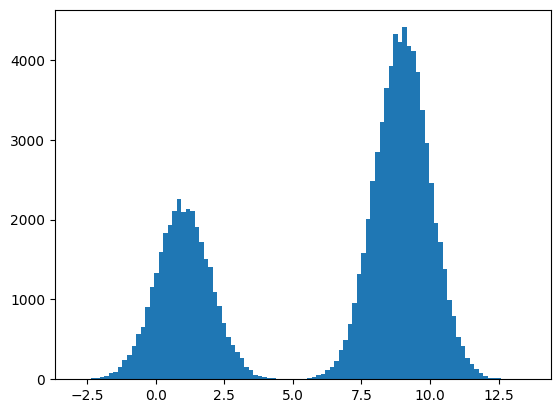

In [6]:
mu = [randint(0,10) for i in range(3)]
sigma = np.ones(3)#[randint(2,5)*random() for i in range(3)]
p = [random() for i in range(5)]
p[2] = 1 - p[0] - p[1]

N = 100000
echantillon_norm = [norm(mu[i], sigma[i]).rvs(N) for i in range(3)]
echantillon = [echantillon_norm[randint(0,2)][randint(0,N-1)] for i in range(N)]

plt.hist(echantillon, bins = 100)
plt.show()

In [7]:
F = 3

In [25]:
def EM_algorithm_step(pi, theta, x, n, F):
  new_rho = np.zeros((n,F))
  s = np.zeros(n)
  p = np.zeros((n,F))
  for i in range(n):
    for y in range(F):
      p[i,y] = 1/np.sqrt(2*np.pi*theta[y,1])*np.exp(-(x[i]-theta[y,0])**2/(2*theta[y,1]))
      s[i]+=pi[y]*p[i,y]
  for i in range(n):
    for y in range(F):
      new_rho[i,y] = pi[y]*p[i,y]/s[i]
  for y in range(F):
    new_pi=0
    for i in range(n):
      new_pi += new_rho[i,y]/n
    pi[y] = new_pi
  new_theta = np.zeros((F,2))
  for y in range(F):
    s1 = 0
    for i in range(n):
      s1 += new_rho[i,y]*x[i]
    new_theta[y,0] = s1/(n*pi[y])
    s2 = 0
    for i in range(n):
      s2 += new_rho[i,y]*(x[i] - theta[y,0])**2
    new_theta[y,1] = s2/(n*pi[y])
  return pi, new_theta

def EM_algorithm(n: int, F: int, x: np.array, pi0: np.array, theta0: np.array):
  pi, theta = pi0, theta0
  liste_pi, liste_theta = [np.copy(pi)], [np.copy(theta)]
  j=0
  while j<10:
    pi, theta = EM_algorithm_step(pi, theta, x, n, F)
    liste_pi.append(np.copy(pi))
    liste_theta.append(np.copy(theta))
    j += 1
  return pi, theta, liste_pi, liste_theta


In [24]:
indices = np.arange(N)
np.random.shuffle(indices)
echantillon_shuffled = []
for i in indices:
  echantillon_shuffled.append(echantillon[i])
pi0 = np.zeros(F)
theta0 = np.zeros((F,2))
for y in range(F):
  pi0[y] = 1/F

for y in range(F):
  theta0[y,0] += np.mean(echantillon_shuffled[y*N//F : (y+1)*N//F])
  for i in range(y*N//F, (y+1)*N//F):
    theta0[y,1] += 1/N*(echantillon_shuffled[i]-theta0[y,0])**2
pi, theta, liste_pi, liste_theta = EM_algorithm(N, F, echantillon, pi0, theta0)
print( "pi = ", pi)
print(" theta = ", theta)

[[ 6.34851518 15.15241615]
 [ 0.          0.        ]
 [ 0.          0.        ]]
[[ 6.34851518 15.15241615]
 [ 6.33315002 15.23395137]
 [ 0.          0.        ]]
[[ 6.34851518 15.15241615]
 [ 6.33315002 15.23395137]
 [ 6.32828201 15.20085712]]
[[ 6.35207862 15.15107186]
 [ 0.          0.        ]
 [ 0.          0.        ]]
[[ 6.35207862 15.15107186]
 [ 6.33003135 15.2176392 ]
 [ 0.          0.        ]]
[[ 6.35207862 15.15107186]
 [ 6.33003135 15.2176392 ]
 [ 6.32785801 15.21833153]]
[[ 6.3557434  15.14165926]
 [ 0.          0.        ]
 [ 0.          0.        ]]
[[ 6.3557434  15.14165926]
 [ 6.3282332  15.21978423]
 [ 0.          0.        ]]
[[ 6.3557434  15.14165926]
 [ 6.3282332  15.21978423]
 [ 6.32600288 15.22539455]]
[[ 6.36017748 15.1291307 ]
 [ 0.          0.        ]
 [ 0.          0.        ]]
[[ 6.36017748 15.1291307 ]
 [ 6.32625073 15.22498734]
 [ 0.          0.        ]]
[[ 6.36017748 15.1291307 ]
 [ 6.32625073 15.22498734]
 [ 6.32356378 15.23241237]]
[[ 6.36563649 15

In [30]:
pi0 = np.ones(F)/F
mu0 = np.linspace(min(echantillon), max(echantillon), F)
sigma0 = np.ones(F)
theta0 = np.stack((mu0, sigma0), axis = -1)

pi, theta, liste_pi, liste_theta = EM_algorithm(N, F, echantillon, pi0, theta0)
print( "pi = ", pi)
print(" theta = ", theta)

pi =  [0.33330445 0.283156   0.38353955]
 theta =  [[1.00823358 0.9995942 ]
 [8.93977702 1.34118492]
 [9.04533016 0.74825594]]


In [28]:
import ipywidgets as widgets  # interactive display
%config InlineBackend.figure_format = 'retina'


In [33]:
@widgets.interact(etape=widgets.IntSlider(0, min=1, max=len(liste_pi),
                                              description="Etape"))

def progression(etape=0):
  x = np.linspace(min(echantillon), max(echantillon), 200)
  nb, _, _ = plt.hist(echantillon, bins = 100)
  for i in range(F):
      plt.plot(x, norm(liste_theta[etape-1][i][0],liste_theta[etape-1][i][1]).pdf(x)*liste_pi[etape-1][i]*max(nb)*np.sqrt(2*np.pi))
  plt.show()

interactive(children=(IntSlider(value=1, description='Etape', max=11, min=1), Output()), _dom_classes=('widget…

In [31]:
liste_theta = np.array(liste_theta)
liste_mu = np.split(liste_theta,2, axis = 2)[0]
liste_sigma = np.split(liste_theta,2, axis = 2)[1]

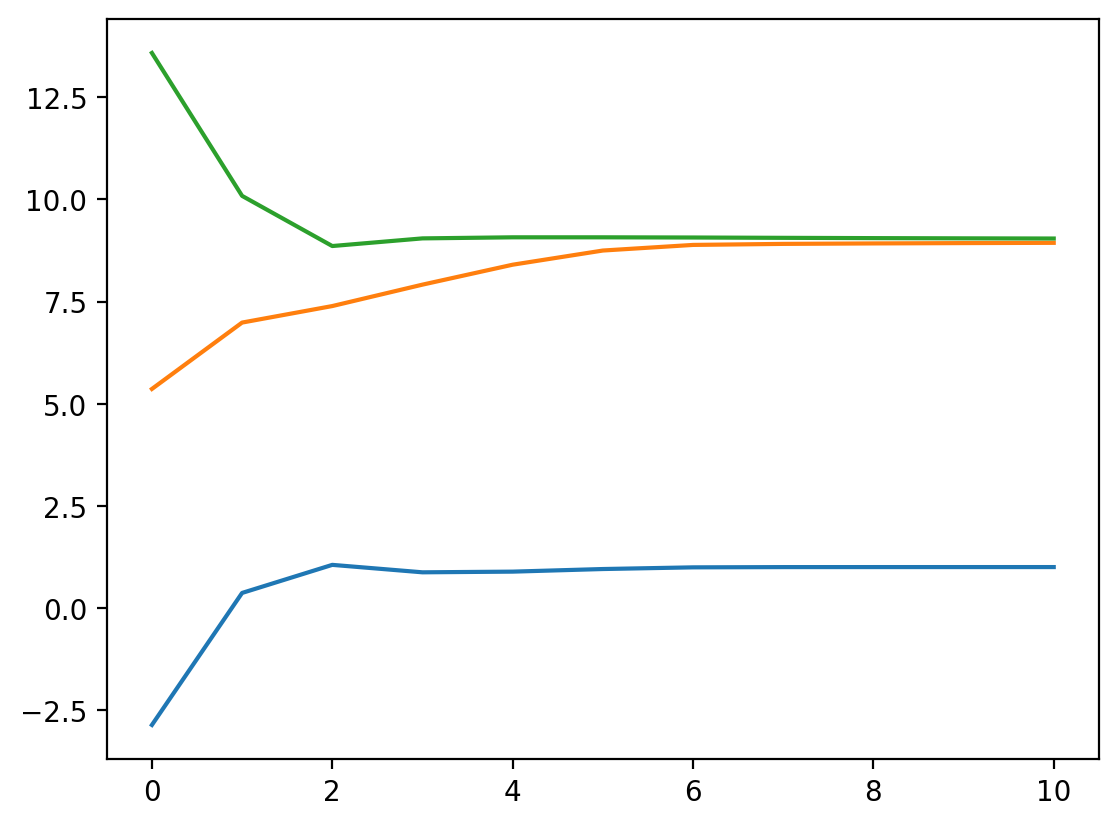

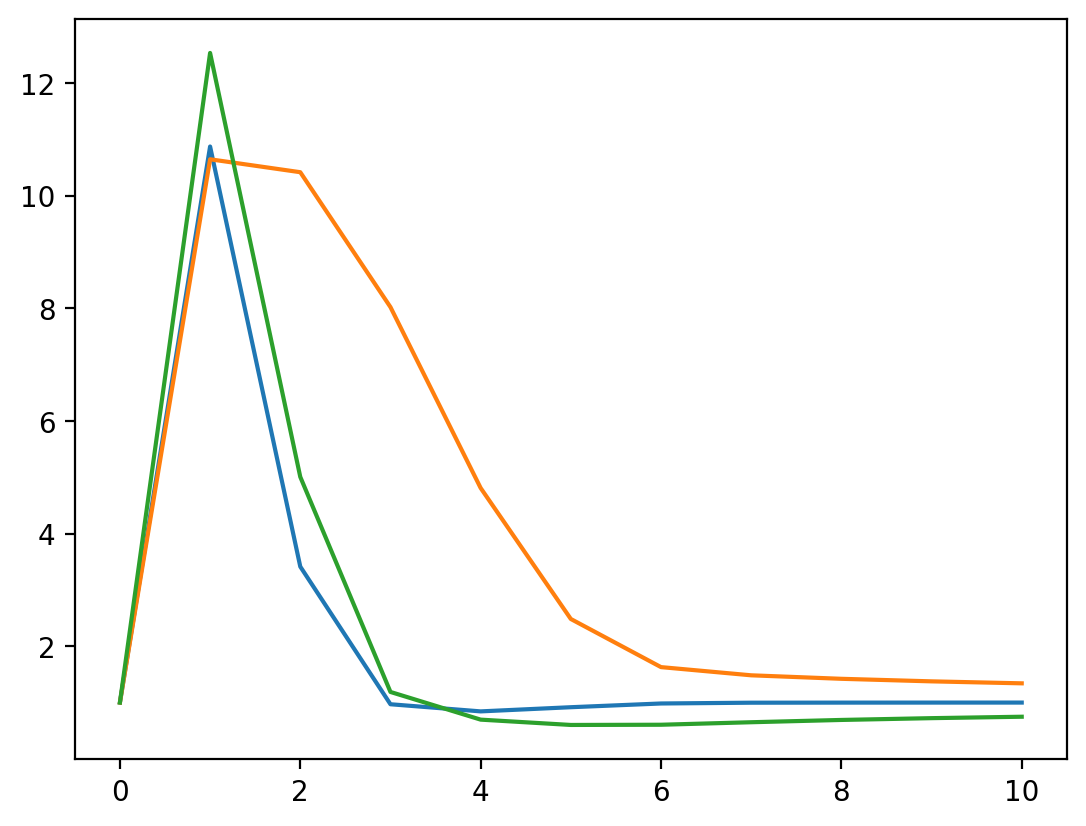

In [32]:
for i in range(F):
    plt.plot(np.squeeze(np.split(liste_mu, 3, axis = 1)[i]))
plt.show()
for i in range(F):
    plt.plot(np.squeeze(np.split(liste_sigma, 3, axis = 1)[i]))
plt.show()